# Factor Portfolio – US

**Pipeline:** Runs the same script and data loading as `run_all.py` (all factors: Value, Momentum, Liquidity, Quality, Yield/BETA0–BETA2, Low Vol), then builds the US factor return matrix. No need to run factors or `run_all.py` beforehand.

**Directory structure:**
- Inputs: `src/`, `config.py`, data as required by factor modules.
- Outputs: `outputs/factors/`, `outputs/portfolio_us/`, **`outputs/plots/us/`** (all figures from this notebook).

**Parameters:** Weights and settings from `config.py` (`DEFAULT_WEIGHTS_US`). Run notebook from project root.

## Setup, load pipeline, build factor matrix

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

PLOTS_DIR = ROOT / "outputs" / "plots" / "us"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

from run_all import run_all_factors, build_factor_matrix
import config

factor_dfs = run_all_factors()
factor_returns = build_factor_matrix(factor_dfs, 'us')
factor_returns = factor_returns.dropna(how='all')

weights = {k.replace('_US',''): v for k, v in config.DEFAULT_WEIGHTS_US.items() if k.replace('_US','') in factor_returns.columns}
weighted_ret = sum(factor_returns[c].fillna(0) * weights.get(c, 0) for c in factor_returns.columns if c in weights)
weighted_ret = pd.Series(weighted_ret, index=factor_returns.index)

print('✓ US factor matrix:', factor_returns.shape)
display(factor_returns.tail())

/Applications/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/Applications/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,



1/6 VALUE FACTOR (VAL)
VALUE FACTOR CALCULATION (Book-to-Market)

[1/6] Fetching US data...
Fetching US value data...
  Loading bvps...
  Loading shares...
  Loading mcap...
  Loading prices...

[2/6] Fetching EU data...
Fetching EU value data...
  Loading bvps...
  Loading shares...
  Loading mcap...
  Loading returns...

[3/6] Calculating Book-to-Market ratios...

[4/6] Generating value signals...

[5/6] Creating 12-month overlapping portfolios...

[6/6] Calculating value factor returns...

Saving outputs to /Users/polina/Downloads/Minerva Code/outputs/factors/...


/Users/polina/Downloads/Minerva Code/src/value.py:352: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.8' currently installed).
  value_returns.to_excel(f'{output_dir}/value_returns.xlsx')


  ✓ Saved value_returns.xlsx
  ✓ Saved value_regional.xlsx

VALUE FACTOR COMPLETE
VAL_US   Sharpe: -0.830
VAL_EU   Sharpe: -0.159
VAL      Sharpe: -0.531

Loading stock returns (cached if files exist)...


/Users/polina/Downloads/Minerva Code/src/value.py:356: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.8' currently installed).
  combined.to_excel(f'{output_dir}/value_regional.xlsx')


...

  ✓ Saved beta2_regional.xlsx
  ✓ Saved yield_factors_all.xlsx

YIELD FACTOR CALCULATION COMPLETE

Factor Summary (Combined):
  BETA0 : mean=-0.0000, std= 0.9833, obs=144
  BETA1 : mean=-0.0000, std= 0.9584, obs=144
  BETA2 : mean= 0.0000, std= 0.9238, obs=144

6/6 LOW VOLATILITY FACTOR (LVOL)
LOW VOLATILITY FACTOR CALCULATION

[1/3] Calculating US low-vol factor (window=60 days)...


/Users/polina/Downloads/Minerva Code/src/yield_factor.py:232: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.8' currently installed).
  simple_df.to_excel(f'{output_dir}/beta{beta_num}_returns.xlsx')
/Users/polina/Downloads/Minerva Code/src/yield_factor.py:235: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.8' currently installed).
  combined.to_excel(f'{output_dir}/yield_factors_all.xlsx')


  ✓ US low-vol: 85 monthly observations
    Sharpe: -0.655

[2/3] Calculating EU low-vol factor...
  ✓ EU low-vol: 85 monthly observations
    Sharpe: -0.568

[3/3] Combining regions...

Saving outputs to /Users/polina/Downloads/Minerva Code/outputs/factors/...
  ✓ Saved lowvol_returns.xlsx
  ✓ Saved lowvol_regional.xlsx

LOW VOLATILITY FACTOR COMPLETE
Combined Low-Vol Sharpe: -0.650
✓ US factor matrix: (189, 8)


/Users/polina/Downloads/Minerva Code/src/lowvol.py:160: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.8' currently installed).
  lowvol_returns.to_excel(f'{output_dir}/lowvol_returns.xlsx')
/Users/polina/Downloads/Minerva Code/src/lowvol.py:164: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.8' currently installed).
  combined.to_excel(f'{output_dir}/lowvol_regional.xlsx')


,VAL,MOM,LIQ,QLT,LVOL,BETA0,BETA1,BETA2
2025-06-30,0.005059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-31,-0.008668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-31,0.043736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-30,0.006205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-31,0.005181,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Calculated output metrics (full table)

In [2]:
def performance_stats(df):
    stats = {}
    for col in df.columns:
        ret = df[col].dropna()
        if len(ret) < 2: continue
        ann_ret = ret.mean() * 12
        ann_vol = ret.std() * np.sqrt(12)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
        cum = (1 + ret).cumprod()
        cum_ret = cum.iloc[-1] - 1
        dd = (cum - cum.cummax()) / cum.cummax()
        max_dd = dd.min()
        win_rate = (ret > 0).mean() * 100
        skew = ret.skew()
        kurt = ret.kurtosis()
        stats[col] = {
            'Ann. Return': ann_ret, 'Ann. Vol': ann_vol, 'Sharpe': sharpe,
            'Cum. Return': cum_ret, 'Max DD': max_dd,
            'Win Rate %': win_rate, 'Skewness': skew, 'Kurtosis': kurt
        }
    return pd.DataFrame(stats).T

perf = performance_stats(factor_returns)
print('Per-factor metrics (US):')
display(perf.round(4))

# Weighted portfolio metrics
wp_stats = performance_stats(pd.DataFrame({'Weighted (config)': weighted_ret}))
print('\nWeighted portfolio (config weights):')
display(wp_stats.round(4))

Per-factor metrics (US):


,Ann. Return,Ann. Vol,Sharpe,Cum. Return,Max DD,Win Rate %,Skewness,Kurtosis
VAL,-0.0846,0.1020,-0.8295,-0.7583,-0.7684,38.6243,-0.0247,3.3094
MOM,0.0155,0.2059,0.0752,-0.0413,-0.4034,61.1765,-0.4788,0.9693
QLT,0.0058,0.0067,0.8537,0.0722,-0.0080,28.7671,2.3189,10.6251
LVOL,-0.1678,0.2560,-0.6554,-0.7642,-0.8205,42.3529,-0.7532,1.5029
BETA0,-0.0000,3.4641,-0.0000,-1.0000,-1.0001,47.9167,-0.0024,-0.3662
BETA1,-0.0000,3.4641,-0.0000,-1.0000,-1.0004,45.8333,0.4129,-0.7237
BETA2,0.0000,3.4641,0.0000,-1.0000,-1.7561,45.1389,0.4503,0.6006



Weighted portfolio (config weights):


,Ann. Return,Ann. Vol,Cum. Return,Kurtosis,Max DD,Sharpe,Skewness,Win Rate %
Weighted (config),-0.03,0.3942,-0.8334,0.7951,-0.9989,-0.076,-0.6616,51.3228


## Factor returns over time

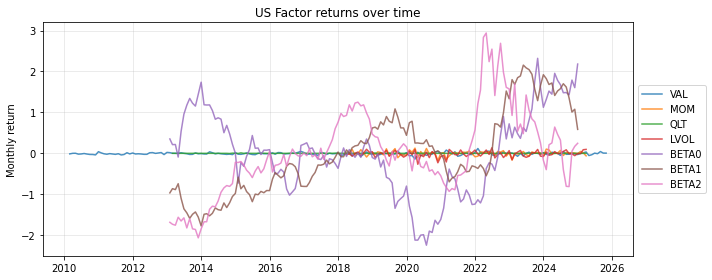

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for col in factor_returns.columns:
    s = factor_returns[col].dropna()
    if len(s) > 0: ax.plot(s.index, s, label=col, alpha=0.8)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Monthly return')
ax.set_title('US Factor returns over time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'factor_returns_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Cumulative returns (1$ invested per factor) & Sharpe bar

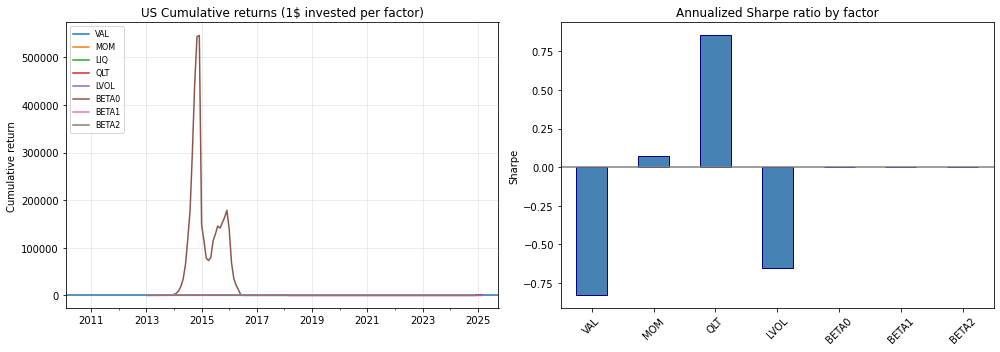

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cum = (1 + factor_returns).cumprod()
cum.plot(ax=axes[0])
axes[0].set_title('US Cumulative returns (1$ invested per factor)')
axes[0].set_ylabel('Cumulative return')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

perf['Sharpe'].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='navy')
axes[1].set_title('Annualized Sharpe ratio by factor')
axes[1].set_ylabel('Sharpe')
axes[1].axhline(0, color='gray', linestyle='-')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'cumulative_and_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation heatmap (factor returns)

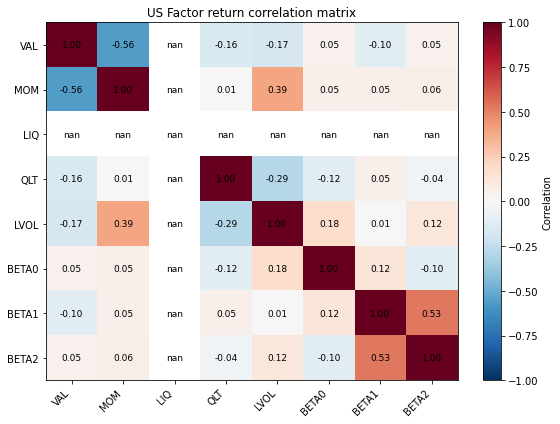

,VAL,MOM,LIQ,QLT,LVOL,BETA0,BETA1,BETA2
VAL,1.000,-0.557,NaN,-0.155,-0.170,0.045,-0.105,0.046
MOM,-0.557,1.000,NaN,0.005,0.391,0.047,0.048,0.056
LIQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
QLT,-0.155,0.005,NaN,1.000,-0.286,-0.115,0.052,-0.039
LVOL,-0.170,0.391,NaN,-0.286,1.000,0.178,0.005,0.116
BETA0,0.045,0.047,NaN,-0.115,0.178,1.000,0.122,-0.104
BETA1,-0.105,0.048,NaN,0.052,0.005,0.122,1.000,0.531
BETA2,0.046,0.056,NaN,-0.039,0.116,-0.104,0.531,1.000


In [6]:
corr = factor_returns.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('US Factor return correlation matrix')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
display(corr.round(3))

## Return distributions (histograms by factor)

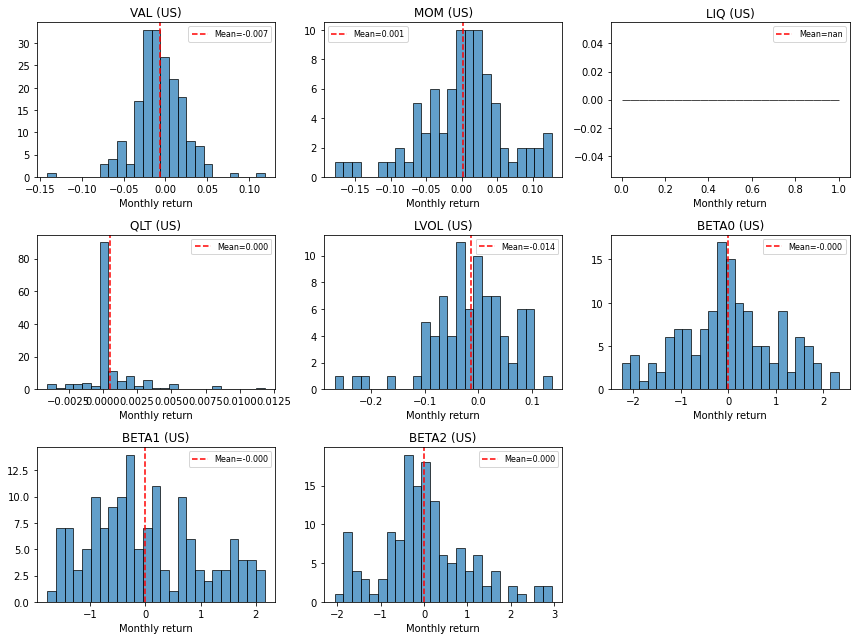

In [7]:
cols = factor_returns.columns.tolist()
n = len(cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = np.atleast_2d(axes)
for idx, col in enumerate(cols):
    r, c = idx // ncols, idx % ncols
    ax = axes[r, c]
    ser = factor_returns[col].dropna()
    ax.hist(ser, bins=25, edgecolor='black', alpha=0.7)
    ax.axvline(ser.mean(), color='red', linestyle='--', label=f'Mean={ser.mean():.3f}')
    ax.set_title(f'{col} (US)')
    ax.set_xlabel('Monthly return')
    ax.legend(fontsize=8)
for idx in range(len(cols), nrows * ncols):
    r, c = idx // ncols, idx % ncols
    axes[r, c].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Weighted portfolio cumulative return

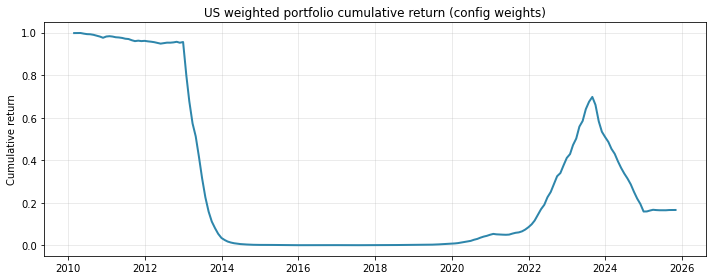

✓ All plots saved to /Users/polina/Downloads/Minerva Code/outputs/plots/us


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
cum = (1 + weighted_ret).cumprod()
ax.plot(cum.index, cum.values, color='#2E86AB', linewidth=2)
ax.set_title('US weighted portfolio cumulative return (config weights)')
ax.set_ylabel('Cumulative return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'cumulative_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ All plots saved to', PLOTS_DIR)